In [1]:
import pandas as pd
import numpy as np
from ast import literal_eval
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, r2_score
import math
import os
from joblib import dump, load

Batch_Size = 64
scaler_path     = './models/mlp_select/scaler.joblib'
checkpoint_path = './models/mlp_select/checkpoint_mlp.pth'
best_model_path = './models/mlp_select/best_model_mlp.pth'

# 训练配置
epochs = 10000
start_epoch = 0

# 1. 读取数据
df = pd.read_csv('hardness_curve_dataset.csv')

# 2. 解析 hv_data 为数值数组
df['hv_data'] = df['hv_data'].apply(lambda x: literal_eval(x) if isinstance(x, str) else x)
hv_array = np.array(df['hv_data'].tolist())  # (样本数, 序列长度)

# 3. 提取输入特征（排除'Image_Name' 和 'hv_data' 列）
# feature_columns = ["Image_Name", 'C', 'Si', 'Mn', 'P', 'Cr', 'Perimeter', 'Aspect_Ratio',
#                    'Compactness', 'Density', 'Uniformity', 'carburizing_temp', 'temp_gradient']
feature_columns = [
    "Image_Name",
    "C","Si","Mn","Cr","Fe","temp_gradient",
    "Perimeter","Aspect_Ratio","Circularity","Compactness","Density","Mean_Spacing","Uniformity",
    'carburizing_temp', 'tempering_temp',
    "Density_phy","ThermalConductivity","BulkModulus","SpecificHeatCapacity"
]
X = df[feature_columns[1:]].values
Y = hv_array

# 4. 划分训练和测试集
# X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
# 4. 划分训练和测试集（同时分割图像名称）
image_names = df['Image_Name'].values  # 提取所有图像名称
X_train, X_test, y_train, y_test, img_names_train, img_names_test = train_test_split(
    X, Y, image_names, test_size=0.2, random_state=42
)

## train MLP

In [2]:

# 5. 特征标准化（包含标准化器状态保存/加载）
scaler = StandardScaler()
if os.path.exists(scaler_path):
    scaler = load(scaler_path)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)
else:
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    dump(scaler, scaler_path)

# 转换数据类型为float32
X_train_np = X_train.astype(np.float32)
X_test_np = X_test.astype(np.float32)
y_train_np = y_train.astype(np.float32)
y_test_np = y_test.astype(np.float32)

# 转换为PyTorch张量
X_train_tensor = torch.tensor(X_train_np)
y_train_tensor = torch.tensor(y_train_np)
X_test_tensor = torch.tensor(X_test_np)
y_test_tensor = torch.tensor(y_test_np)

# 创建数据加载器
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=Batch_Size, shuffle=True)

# 定义MLP模型
class MLPRegressor(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MLPRegressor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )
        
    def forward(self, x):
        return self.net(x)

# 初始化模型和优化器
input_dim = X_train_tensor.shape[1]
output_dim = y_train_tensor.shape[1]
mlp_model = MLPRegressor(input_dim, output_dim)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.001)

best_loss = float('inf')

# 加载检查点（如果存在）
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    mlp_model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_loss = checkpoint['best_loss']
    print(f"Loaded checkpoint from epoch {checkpoint['epoch']}. Resuming training...")

# 训练循环
for epoch in range(start_epoch, epochs):
    mlp_model.train()
    running_loss = 0.0
    
    # 训练步骤
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = mlp_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    # 计算测试集损失
    mlp_model.eval()
    with torch.no_grad():
        test_loss = criterion(mlp_model(X_test_tensor), y_test_tensor).item()
    
    # 保存最佳模型
    if test_loss < best_loss:
        best_loss = test_loss
        torch.save(mlp_model.state_dict(), best_model_path)
        print(f"Epoch {epoch+1}: New best model saved with test loss {test_loss:.4f}")
    
    # 保存检查点
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': mlp_model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_loss': best_loss,
    }
    torch.save(checkpoint, checkpoint_path)
    
    # 打印训练信息（每10个epoch）
    if (epoch+1) % 10 == 0:
        avg_train_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{epochs}], 训练Loss: {avg_train_loss:.4f}, 测试Loss: {test_loss:.4f}")

# 最终评估最佳模型
mlp_model.load_state_dict(torch.load(best_model_path))
mlp_model.eval()
with torch.no_grad():
    y_pred_test = mlp_model(X_test_tensor).numpy()
    y_true_test = y_test_tensor.numpy()

mse = mean_squared_error(y_true_test, y_pred_test)
rmse = math.sqrt(mse)
r2 = r2_score(y_true_test, y_pred_test)
print(f"\n最佳模型性能 - MSE: {mse:.3f}, RMSE: {rmse:.3f}, R²: {r2:.3f}")

Loaded checkpoint from epoch 9999. Resuming training...

最佳模型性能 - MSE: 10.784, RMSE: 3.284, R²: 0.989


/tmp/ipykernel_1349011/3038932681.py:54: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)
/tmp/ipykernel_1349011/3038932681.py:101: Fut

## test

/tmp/ipykernel_1349011/759647463.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mlp_model.load_state_dict(torch.load(best_model_path))



最佳模型性能 - MSE: 10.784, RMSE: 3.284, R²: 0.989

随机样本预测结果对比：

图像名称: 066.png
真实值: [733.46 727.94 713.31 714.13 671.23 656.69 617.23 596.76 568.21 525.71
 483.23 473.12 455.9  450.43]
预测值: [733.21 727.93 713.2  713.73 670.37 656.21 616.76 596.25 567.93 525.1
 482.78 473.19 455.17 449.65]
样本MSE: 0.249, RMSE: 0.499

图像名称: 020.png
真实值: [712.88 655.12 642.61 609.03 584.25 558.79 528.59 514.27 507.45 519.5
 518.41 518.41 518.41 518.41]
预测值: [718.98 660.54 647.59 615.1  589.88 564.48 533.47 519.32 511.01 523.44
 522.21 522.64 522.75 522.76]
样本MSE: 24.264, RMSE: 4.926

图像名称: 075.png
真实值: [706.64 685.31 653.9  652.62 617.53 612.95 561.45 530.59 482.02 470.72
 437.64 426.82 418.81 422.03]
预测值: [708.42 686.53 655.76 653.9  618.96 614.27 561.81 532.26 484.23 471.19
 438.73 427.12 420.41 423.25]
样本MSE: 1.921, RMSE: 1.386

图像名称: 014.png
真实值: [712.88 655.12 642.61 609.03 584.25 558.79 528.59 514.27 507.45 519.5
 518.41 518.41 518.41 518.41]
预测值: [707.5  649.55 636.82 604.76 580.26 553.67 522.61 510.55 5

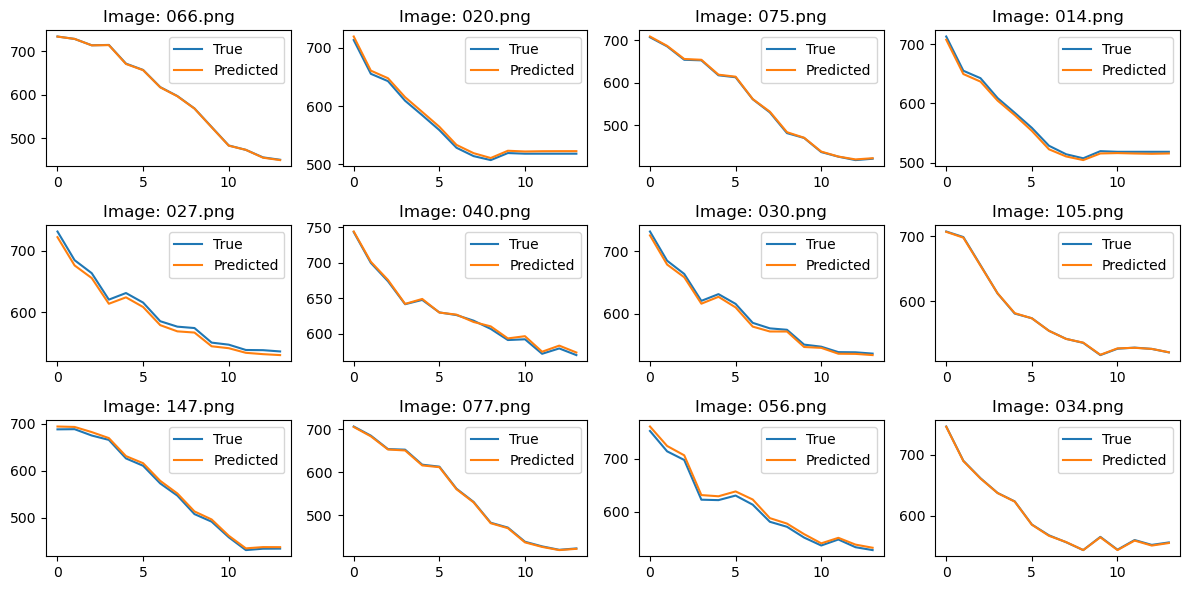

In [3]:
# 最终评估最佳模型（添加图像名称展示）
mlp_model.load_state_dict(torch.load(best_model_path))
mlp_model.eval()
with torch.no_grad():
    y_pred_test = mlp_model(X_test_tensor).numpy()
    y_true_test = y_test_tensor.numpy()

# 整体性能评估
mse = mean_squared_error(y_true_test, y_pred_test)
rmse = math.sqrt(mse)
r2 = r2_score(y_true_test, y_pred_test)
print(f"\n最佳模型性能 - MSE: {mse:.3f}, RMSE: {rmse:.3f}, R²: {r2:.3f}")

# 随机抽取5个样本展示预测结果
np.random.seed(42)  # 固定随机种子保证可重复性
sample_indices = np.random.choice(len(y_true_test), 12, replace=False)

print("\n随机样本预测结果对比：")
for idx in sample_indices:
    # 获取样本信息
    img_name = img_names_test[idx]
    true_values = y_true_test[idx]
    pred_values = y_pred_test[idx]
    
    # 计算单个样本指标
    sample_mse = mean_squared_error(true_values, pred_values)
    sample_rmse = math.sqrt(sample_mse)
    
    # 打印结果
    # print(f"\n图像名称: {img_name}")
    # print(f"真实值前5点: {np.round(true_values[:5], 2)}")
    # print(f"预测值前5点: {np.round(pred_values[:5], 2)}")
    # print(f"样本MSE: {sample_mse:.3f}, RMSE: {sample_rmse:.3f}")
    print(f"\n图像名称: {img_name}")
    print(f"真实值: {np.round(true_values, 2)}")
    print(f"预测值: {np.round(pred_values, 2)}")
    print(f"样本MSE: {sample_mse:.3f}, RMSE: {sample_rmse:.3f}")

# 可视化展示（可选，需要matplotlib）
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for i, idx in enumerate(sample_indices, 1):
    plt.subplot(3, 4, i)
    plt.plot(y_true_test[idx], label='True')
    plt.plot(y_pred_test[idx], label='Predicted')
    plt.title(f"Image: {img_names_test[idx]}")
    plt.legend()
plt.tight_layout()
plt.show()